In [1]:
# Step 1: Specify the path to the "experiment_analyses" folder in your system (after cloning the repo)
# This step is because I have a separate folder in the repo that contains the Jupyter Notebooks for organization purposes
import warnings
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

experiment_analyses_dir = r"C:\Users\graci\OneDrive\Documents\Github\driving_exp_1_analyses\experiment_analyses"  # Replace with your desired directory
# r"C:\Users\graci\Dropbox\PAndA\Thesis Experiment 1\scripts\experiment_analyses"  # Replace with your desired directory
os.chdir(experiment_analyses_dir)


# Step 2: Specify the location of file paths contain the main_data folder
# I will share a Dropbox folder with you that contains these folders, so you can just copy and paste your file system file path to these
# Note that the files in these folders should be treated as immutable
import preprocess

SUBJECT_PATH = "C:/Users/graci/Dropbox/PAndA/Thesis Experiment 3/data/main_data" 

warnings.filterwarnings("ignore")
subject_dict = preprocess.run(SUBJECT_PATH)
print('Success!')

def getCostMatrix(dist_mat):
    """
    Find minimum-cost path through matrix `dist_mat` using dynamic programming.

    The cost of a path is defined as the sum of the matrix entries on that
    path. See the following for details of the algorithm:

    - http://en.wikipedia.org/wiki/Dynamic_time_warping
    - https://www.ee.columbia.edu/~dpwe/resources/matlab/dtw/dp.m

    The notation in the first reference was followed, while Dan Ellis's code
    (second reference) was used to check for correctness. Returns a list of
    path indices and the cost matrix.
    """

    N, M = dist_mat.shape

    # Initialize the cost matrix
    cost_mat = np.zeros((N + 1, M + 1))
    for i in range(1, N + 1):
        cost_mat[i, 0] = np.inf
    for i in range(1, M + 1):
        cost_mat[0, i] = np.inf

    # Fill the cost matrix while keeping traceback information
    traceback_mat = np.zeros((N, M))
    for i in range(N):
        for j in range(M):
            penalty = [
                cost_mat[i, j],      # match (0)
                cost_mat[i, j + 1],  # insertion (1)
                cost_mat[i + 1, j]]  # deletion (2)
            i_penalty = np.argmin(penalty)
            cost_mat[i + 1, j + 1] = dist_mat[i, j] + penalty[i_penalty]
            traceback_mat[i, j] = i_penalty

    # Traceback from bottom right
    i = N - 1
    j = M - 1
    path = [(i, j)]
    while i > 0 or j > 0:
        tb_type = traceback_mat[i, j]
        if tb_type == 0:
            # Match
            i = i - 1
            j = j - 1
        elif tb_type == 1:
            # Insertion
            i = i - 1
        elif tb_type == 2:
            # Deletion
            j = j - 1
        path.append((i, j))

    # Strip infinity edges from cost_mat before returning
    cost_mat = cost_mat[1:, 1:]
    return (path[::-1], cost_mat) # Return cost_mat and path


Success!


In [2]:
# Useful references -------------------------
control_group_ids = ["agony","both","cargo","cheek","cub", "desk","dingy","fetch","final","floss","fried","mount","pagan","slot", "snarl","spoof","tribe", "untie","width","wish"]
scrambled_segments_group_ids = ["brave","comic", "crop", "dial","donor","even","gave","gore","gray", "hump","jury","mud", "outer", "ozone", "relax","riot", "salon","unit", "upon", "zebra"]
scrambled_landmarks_group_ids = ["arena","chain","cloth","crept", "disk","elm","flask","flip","game","grab","grant","guy","jam","line","marry","ounce","river","roar","shred", "spoon"]
control_trajectories = []
scrambled_segment_trajectories = []
scrambled_landmarks_trajectories = []

# Bundle into a group dictionary for cleaner iteration
group_dict = {
    "control": (control_group_ids, control_trajectories),
    "scrambled_segments": (scrambled_segments_group_ids, scrambled_segment_trajectories),
    "scrambled_landmarks": (scrambled_landmarks_group_ids, scrambled_landmarks_trajectories)
}

# Track segments
track_pieces = ['chicane', 'triple_s', 'symmetric_parabolic', 'traffic_circle',
                'asymmetric_parabolic_2', 't_turn', 'asymmetric_parabolic_1', 'spiral']

# Process each group
for group_name, (subject_ids, trajectory_list) in group_dict.items():
    for subject_id in subject_ids:
        subject_object = subject_dict[subject_id]
        trial_object_eleven = subject_object.trials[10]
        trial_df_eleven = trial_object_eleven.trajectory_df
        trajectory_list.append(trial_df_eleven[['pos_x', 'pos_z']].values)

In [3]:
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

def compute_barycenter(trajectories, subject_ids, label=""):
    """
    Computes the barycenter trajectory for a group of trajectories using pairwise averaging along DTW paths.
    """
    initial_traj = trajectories[0]  # Start with the first trajectory
    for i in range(len(trajectories) - 1):
        new_barycenter = []
        dist_matrix = cdist(initial_traj, trajectories[i + 1], 'euclidean')  # Compute distance matrix
        path, cost = getCostMatrix(dist_matrix)  # Assumes this function returns alignment path and cost
        for j in range(len(path)):
            new_barycenter.append((initial_traj[path[j][0]] + trajectories[i + 1][path[j][1]]) / 2)
        initial_traj = new_barycenter
        print(f'{subject_ids[i]} updated Barycenter for {label}')
        x, y = zip(*initial_traj)
        plt.plot(x, y)
    return new_barycenter

# Compute barycenters for each group
dba_control = compute_barycenter(control_trajectories, control_group_ids, label="Control")
dba_scrambled_segments = compute_barycenter(scrambled_segment_trajectories, scrambled_segments_group_ids, label="Scrambled Segments")
dba_scrambled_landmarks = compute_barycenter(scrambled_landmarks_trajectories, scrambled_landmarks_group_ids, label="Scrambled Landmarks")


KeyboardInterrupt: 

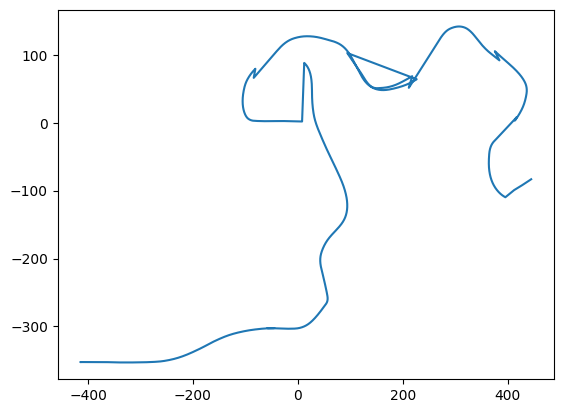

In [18]:
import pandas as pd
dba_fam = initial_traj
x1, y1 = zip(*dba_fam) #fam unzip and plot
plt.plot(x1, y1)
pd.DataFrame(dba_fam).to_csv(r"C:\Users\singel\Downloads\DBA_fam_traj.csv")


atom updated Barycenter
brim updated Barycenter
chef updated Barycenter
clerk updated Barycenter
debt updated Barycenter
grid updated Barycenter
lens updated Barycenter
limb updated Barycenter
most updated Barycenter
slimy updated Barycenter


KeyboardInterrupt: 

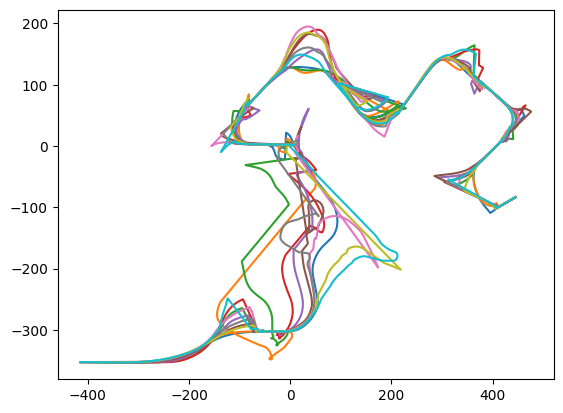

In [19]:

initial_traj = unfamiliar_trajectories[0] # this will be our initial trajectory that we start with and iteratively update
for i in range(0, len(unfamiliar_trajectories) - 1): # Go through each trajectory in this experimental group
    new_barycenter = [] # New Barycenter points added as trajectory is populated
    dist_matrix = cdist(initial_traj, unfamiliar_trajectories[i + 1], 'euclidean') # DTW on inital trajectory (Barycenter) and subject trajectory
    path, cost = getCostMatrix(dist_matrix)    
    # print(path) # Given a list of tuples, each coordinate can index their respective trajectories and be averaged
    for j in range(0, len(path)): # Traverses alignment path to index trajectories and generate points on the Barycenter Trajectory
        new_barycenter.append((initial_traj[path[j][0]] + unfamiliar_trajectories[i + 1][path[j][1]])/2)
    initial_traj = new_barycenter
    print(f'{unfamiliar_group_ids[i]} updated Barycenter')
    x, y = zip(*initial_traj)
    plt.plot(x, y)
dba_unfam = new_barycenter

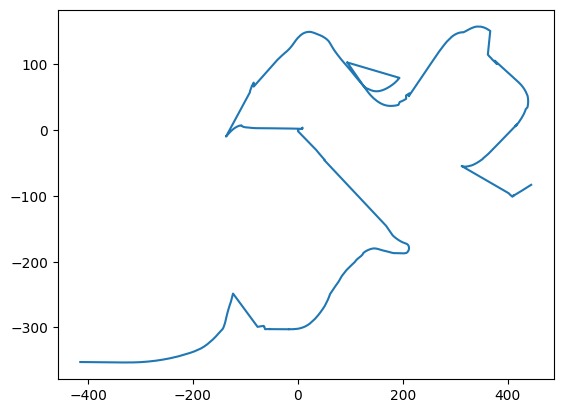

In [20]:
import pandas as pd
dba_unfam = initial_traj
x2, y2 = zip(*dba_unfam) #fam unzip and plot
plt.plot(x2, y2)
pd.DataFrame(dba_unfam).to_csv(r"C:\Users\singel\Downloads\DBA_unfam_traj.csv")


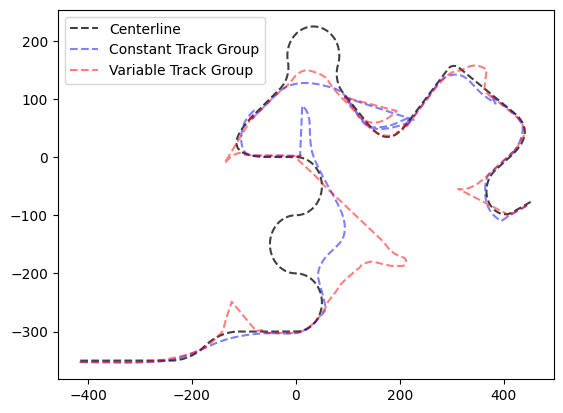

In [32]:
# Get objects associated to a given subject and their trial
subject_object = subject_dict["atom"]
trial_object = subject_object.trials[10]

# Retrieve useful information
trial_map_number = trial_object.map.map_number # map number that subject drove in for a given trial
track_piece_list = trial_object.map.pieces # list of strings that denote the track pieces in the map
track_piece_object_dict = trial_object.pieces # dictionary that contains track_piece names and their associated track_piece_object instantiation
x0, y0 = trial_object.map.centerline_df['x'],trial_object.map.centerline_df['y'] # centerline reference trajectory
plt.plot(x0, y0, label='Centerline', color = 'black', alpha = 0.75, linestyle='--')

# Unzip and plot dba_fam
x1, y1 = zip(*dba_fam)
plt.plot(x1, y1, linestyle='--', label='Constant Track Group', color='blue', alpha = 0.5)  # Dashed line, add label for legend

# Unzip and plot dba_unfam
x2, y2 = zip(*dba_unfam)
plt.plot(x2, y2, linestyle='--', label='Variable Track Group', color='r', alpha = 0.5)  # Dashed line, add label for legend

# Add legend
plt.legend()

# Show plot
plt.show()


In [34]:
dist_matrix = cdist(np.array(list(zip(x1, y1))), np.array(list(zip(x0, y0))), 'euclidean') # DTW on familiar track group's Barycenter and centerline trajectory
path, cost_matrix = getCostMatrix(dist_matrix)# get cost matrix
norm_cost = cost_matrix[cost_matrix.shape[0] - 1][cost_matrix.shape[1] - 1] / (cost_matrix.shape[0] * cost_matrix.shape[1]) # normalization of final cost
print(norm_cost)

0.01106387869685547


In [ ]:
dist_matrix = cdist(np.array(list(zip(x2, y2))), np.array(list(zip(x0, y0))), 'euclidean') # DTW on unfamiliar track group's Barycenter and centerline trajectory
path, cost_matrix = getCostMatrix(dist_matrix)
norm_cost = cost_matrix[cost_matrix.shape[0] - 1][cost_matrix.shape[1] - 1] / (cost_matrix.shape[0] * cost_matrix.shape[1]) # normalization of final cost
print(norm_cost)